In [1]:
import numpy as np
import os 
import cv2
import random
import pandas as pd
import os
import cv2
import random
from pandas import read_excel
from pandas import DataFrame
from sklearn.decomposition import PCA
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import pickle
import matplotlib.pyplot as plt
from all_functions import *

In [2]:
path_in = "./video_train"
path_out = "./Rotation_0_180_pas20_StableTeneurs/Rotation_crop"

In [3]:
videos = []
for video in os.listdir(path_in+"/"):
    videos.append(video)
print(videos)
print(len(videos))

['rl1_pb12-4.mp4', 'rl1_pb17-4.mp4', 'rl1_pb19-4.mp4', 'rl1_pb2-4.mp4', 'rl1_pb30-4.mp4', 'rl1_pb4-4.mp4', 'rl1_pb9-4.mp4', 'rl3_pb12-4.mp4', 'rl3_pb16-4.mp4', 'rl3_pb19-4.mp4', 'rl3_pb30-4.mp4', 'rl3_pb4-4.mp4', 'rl3_pb9-4.mp4', 'rl3_pb9-5.mp4', 'rl4_pb16-4.mp4', 'rl4_pb17-4.mp4', 'rl4_pb19-4.mp4', 'rl4_pb2-4.mp4', 'rl4_pb23-4.mp4', 'rl4_pb30-4.mp4', 'rl4_pb4-4.mp4', 'rl4_pb8-7.mp4', 'rl4_pb9-4.mp4', 'rl4_pb9-5.mp4']
24


In [4]:
def extractImages(pathIn,pathOut):
    images = []
    count = 0
    vidcap = cv2.VideoCapture(pathIn)
    print(pathOut)
    vid= pathIn.split("/")[2].split(".")[0]
    success = True
    while success:
        image_augmented = []
        vidcap.set(cv2.CAP_PROP_POS_MSEC,(count*500)) # added this line
        success,image = vidcap.read()        
        if(success != False):
            image = crop_image_from_center(image,720,720)
            image_height, image_width = image.shape[0:2]
            for i in np.arange(0, 181, 20):
                image_rotated = rotate_image(image, i)
                image_rotated_cropped = crop_around_center(
                    image_rotated,
                    *rotatedRectWithMaxArea(
                        image_width,
                        image_height,
                        math.radians(i)
            )
                
        )
                image_rotated_cropped = crop_image_from_center(image_rotated_cropped,400,400)
                image_augmented.append(image_rotated_cropped)
            if(os.path.exists(pathOut)==False):
                os.mkdir(pathOut)
            c = 0
            for i in image_augmented:
                pathToSave= pathOut + "/" + vid+"-"+str(count)+"-"+str(c)+".jpg"
                cv2.imwrite(pathToSave,i) # save frame as JPEG file
                print("frame "+vid+"-"+str(count)+"-"+str(c)+".jpg",success) 
                c=c+1
        count = count+1 

In [5]:
for video in videos :
    extractImages(path_in+"/"+video, path_out+"/"+video.replace("mp4",""))

./Rotation_0_180_pas20_StableTeneurs/Rotation_crop/rl1_pb12-4.
frame rl1_pb12-4-0-0.jpg True
frame rl1_pb12-4-0-1.jpg True
frame rl1_pb12-4-0-2.jpg True
frame rl1_pb12-4-0-3.jpg True
frame rl1_pb12-4-0-4.jpg True
frame rl1_pb12-4-0-5.jpg True
frame rl1_pb12-4-0-6.jpg True
frame rl1_pb12-4-0-7.jpg True
frame rl1_pb12-4-0-8.jpg True
frame rl1_pb12-4-0-9.jpg True
frame rl1_pb12-4-1-0.jpg True
frame rl1_pb12-4-1-1.jpg True
frame rl1_pb12-4-1-2.jpg True
frame rl1_pb12-4-1-3.jpg True
frame rl1_pb12-4-1-4.jpg True
frame rl1_pb12-4-1-5.jpg True
frame rl1_pb12-4-1-6.jpg True
frame rl1_pb12-4-1-7.jpg True
frame rl1_pb12-4-1-8.jpg True
frame rl1_pb12-4-1-9.jpg True
frame rl1_pb12-4-2-0.jpg True
frame rl1_pb12-4-2-1.jpg True
frame rl1_pb12-4-2-2.jpg True
frame rl1_pb12-4-2-3.jpg True
frame rl1_pb12-4-2-4.jpg True
frame rl1_pb12-4-2-5.jpg True
frame rl1_pb12-4-2-6.jpg True
frame rl1_pb12-4-2-7.jpg True
frame rl1_pb12-4-2-8.jpg True
frame rl1_pb12-4-2-9.jpg True
frame rl1_pb12-4-3-0.jpg True
frame r

frame rl1_pb12-4-27-0.jpg True
frame rl1_pb12-4-27-1.jpg True
frame rl1_pb12-4-27-2.jpg True
frame rl1_pb12-4-27-3.jpg True
frame rl1_pb12-4-27-4.jpg True
frame rl1_pb12-4-27-5.jpg True
frame rl1_pb12-4-27-6.jpg True
frame rl1_pb12-4-27-7.jpg True
frame rl1_pb12-4-27-8.jpg True
frame rl1_pb12-4-27-9.jpg True
frame rl1_pb12-4-28-0.jpg True
frame rl1_pb12-4-28-1.jpg True
frame rl1_pb12-4-28-2.jpg True
frame rl1_pb12-4-28-3.jpg True
frame rl1_pb12-4-28-4.jpg True
frame rl1_pb12-4-28-5.jpg True
frame rl1_pb12-4-28-6.jpg True
frame rl1_pb12-4-28-7.jpg True
frame rl1_pb12-4-28-8.jpg True
frame rl1_pb12-4-28-9.jpg True
frame rl1_pb12-4-29-0.jpg True
frame rl1_pb12-4-29-1.jpg True
frame rl1_pb12-4-29-2.jpg True
frame rl1_pb12-4-29-3.jpg True
frame rl1_pb12-4-29-4.jpg True
frame rl1_pb12-4-29-5.jpg True
frame rl1_pb12-4-29-6.jpg True
frame rl1_pb12-4-29-7.jpg True
frame rl1_pb12-4-29-8.jpg True
frame rl1_pb12-4-29-9.jpg True
frame rl1_pb12-4-30-0.jpg True
frame rl1_pb12-4-30-1.jpg True
frame rl

frame rl1_pb12-4-54-2.jpg True
frame rl1_pb12-4-54-3.jpg True
frame rl1_pb12-4-54-4.jpg True
frame rl1_pb12-4-54-5.jpg True
frame rl1_pb12-4-54-6.jpg True
frame rl1_pb12-4-54-7.jpg True
frame rl1_pb12-4-54-8.jpg True
frame rl1_pb12-4-54-9.jpg True
frame rl1_pb12-4-55-0.jpg True
frame rl1_pb12-4-55-1.jpg True
frame rl1_pb12-4-55-2.jpg True
frame rl1_pb12-4-55-3.jpg True
frame rl1_pb12-4-55-4.jpg True
frame rl1_pb12-4-55-5.jpg True
frame rl1_pb12-4-55-6.jpg True
frame rl1_pb12-4-55-7.jpg True
frame rl1_pb12-4-55-8.jpg True
frame rl1_pb12-4-55-9.jpg True
frame rl1_pb12-4-56-0.jpg True
frame rl1_pb12-4-56-1.jpg True
frame rl1_pb12-4-56-2.jpg True
frame rl1_pb12-4-56-3.jpg True
frame rl1_pb12-4-56-4.jpg True
frame rl1_pb12-4-56-5.jpg True
frame rl1_pb12-4-56-6.jpg True
frame rl1_pb12-4-56-7.jpg True
frame rl1_pb12-4-56-8.jpg True
frame rl1_pb12-4-56-9.jpg True
frame rl1_pb12-4-57-0.jpg True
frame rl1_pb12-4-57-1.jpg True
frame rl1_pb12-4-57-2.jpg True
frame rl1_pb12-4-57-3.jpg True
frame rl

frame rl1_pb17-4-10-2.jpg True
frame rl1_pb17-4-10-3.jpg True
frame rl1_pb17-4-10-4.jpg True
frame rl1_pb17-4-10-5.jpg True
frame rl1_pb17-4-10-6.jpg True
frame rl1_pb17-4-10-7.jpg True
frame rl1_pb17-4-10-8.jpg True
frame rl1_pb17-4-10-9.jpg True
frame rl1_pb17-4-11-0.jpg True
frame rl1_pb17-4-11-1.jpg True
frame rl1_pb17-4-11-2.jpg True
frame rl1_pb17-4-11-3.jpg True
frame rl1_pb17-4-11-4.jpg True
frame rl1_pb17-4-11-5.jpg True
frame rl1_pb17-4-11-6.jpg True
frame rl1_pb17-4-11-7.jpg True
frame rl1_pb17-4-11-8.jpg True
frame rl1_pb17-4-11-9.jpg True
frame rl1_pb17-4-12-0.jpg True
frame rl1_pb17-4-12-1.jpg True
frame rl1_pb17-4-12-2.jpg True
frame rl1_pb17-4-12-3.jpg True
frame rl1_pb17-4-12-4.jpg True
frame rl1_pb17-4-12-5.jpg True
frame rl1_pb17-4-12-6.jpg True
frame rl1_pb17-4-12-7.jpg True
frame rl1_pb17-4-12-8.jpg True
frame rl1_pb17-4-12-9.jpg True
frame rl1_pb17-4-13-0.jpg True
frame rl1_pb17-4-13-1.jpg True
frame rl1_pb17-4-13-2.jpg True
frame rl1_pb17-4-13-3.jpg True
frame rl

frame rl1_pb17-4-37-1.jpg True
frame rl1_pb17-4-37-2.jpg True
frame rl1_pb17-4-37-3.jpg True
frame rl1_pb17-4-37-4.jpg True
frame rl1_pb17-4-37-5.jpg True
frame rl1_pb17-4-37-6.jpg True
frame rl1_pb17-4-37-7.jpg True
frame rl1_pb17-4-37-8.jpg True
frame rl1_pb17-4-37-9.jpg True
frame rl1_pb17-4-38-0.jpg True
frame rl1_pb17-4-38-1.jpg True
frame rl1_pb17-4-38-2.jpg True
frame rl1_pb17-4-38-3.jpg True
frame rl1_pb17-4-38-4.jpg True
frame rl1_pb17-4-38-5.jpg True
frame rl1_pb17-4-38-6.jpg True
frame rl1_pb17-4-38-7.jpg True
frame rl1_pb17-4-38-8.jpg True
frame rl1_pb17-4-38-9.jpg True
frame rl1_pb17-4-39-0.jpg True
frame rl1_pb17-4-39-1.jpg True
frame rl1_pb17-4-39-2.jpg True
frame rl1_pb17-4-39-3.jpg True
frame rl1_pb17-4-39-4.jpg True
frame rl1_pb17-4-39-5.jpg True
frame rl1_pb17-4-39-6.jpg True
frame rl1_pb17-4-39-7.jpg True
frame rl1_pb17-4-39-8.jpg True
frame rl1_pb17-4-39-9.jpg True
frame rl1_pb17-4-40-0.jpg True
frame rl1_pb17-4-40-1.jpg True
frame rl1_pb17-4-40-2.jpg True
frame rl

...

frame rl4_pb8-7-54-0.jpg True
frame rl4_pb8-7-54-1.jpg True
frame rl4_pb8-7-54-2.jpg True
frame rl4_pb8-7-54-3.jpg True
frame rl4_pb8-7-54-4.jpg True
frame rl4_pb8-7-54-5.jpg True
frame rl4_pb8-7-54-6.jpg True
frame rl4_pb8-7-54-7.jpg True
frame rl4_pb8-7-54-8.jpg True
frame rl4_pb8-7-54-9.jpg True
frame rl4_pb8-7-55-0.jpg True
frame rl4_pb8-7-55-1.jpg True
frame rl4_pb8-7-55-2.jpg True
frame rl4_pb8-7-55-3.jpg True
frame rl4_pb8-7-55-4.jpg True
frame rl4_pb8-7-55-5.jpg True
frame rl4_pb8-7-55-6.jpg True
frame rl4_pb8-7-55-7.jpg True
frame rl4_pb8-7-55-8.jpg True
frame rl4_pb8-7-55-9.jpg True
frame rl4_pb8-7-56-0.jpg True
frame rl4_pb8-7-56-1.jpg True
frame rl4_pb8-7-56-2.jpg True
frame rl4_pb8-7-56-3.jpg True
frame rl4_pb8-7-56-4.jpg True
frame rl4_pb8-7-56-5.jpg True
frame rl4_pb8-7-56-6.jpg True
frame rl4_pb8-7-56-7.jpg True
frame rl4_pb8-7-56-8.jpg True
frame rl4_pb8-7-56-9.jpg True
frame rl4_pb8-7-57-0.jpg True
frame rl4_pb8-7-57-1.jpg True
frame rl4_pb8-7-57-2.jpg True
frame rl4_

frame rl4_pb9-4-22-0.jpg True
frame rl4_pb9-4-22-1.jpg True
frame rl4_pb9-4-22-2.jpg True
frame rl4_pb9-4-22-3.jpg True
frame rl4_pb9-4-22-4.jpg True
frame rl4_pb9-4-22-5.jpg True
frame rl4_pb9-4-22-6.jpg True
frame rl4_pb9-4-22-7.jpg True
frame rl4_pb9-4-22-8.jpg True
frame rl4_pb9-4-22-9.jpg True
frame rl4_pb9-4-23-0.jpg True
frame rl4_pb9-4-23-1.jpg True
frame rl4_pb9-4-23-2.jpg True
frame rl4_pb9-4-23-3.jpg True
frame rl4_pb9-4-23-4.jpg True
frame rl4_pb9-4-23-5.jpg True
frame rl4_pb9-4-23-6.jpg True
frame rl4_pb9-4-23-7.jpg True
frame rl4_pb9-4-23-8.jpg True
frame rl4_pb9-4-23-9.jpg True
frame rl4_pb9-4-24-0.jpg True
frame rl4_pb9-4-24-1.jpg True
frame rl4_pb9-4-24-2.jpg True
frame rl4_pb9-4-24-3.jpg True
frame rl4_pb9-4-24-4.jpg True
frame rl4_pb9-4-24-5.jpg True
frame rl4_pb9-4-24-6.jpg True
frame rl4_pb9-4-24-7.jpg True
frame rl4_pb9-4-24-8.jpg True
frame rl4_pb9-4-24-9.jpg True
frame rl4_pb9-4-25-0.jpg True
frame rl4_pb9-4-25-1.jpg True
frame rl4_pb9-4-25-2.jpg True
frame rl4_

frame rl4_pb9-4-50-0.jpg True
frame rl4_pb9-4-50-1.jpg True
frame rl4_pb9-4-50-2.jpg True
frame rl4_pb9-4-50-3.jpg True
frame rl4_pb9-4-50-4.jpg True
frame rl4_pb9-4-50-5.jpg True
frame rl4_pb9-4-50-6.jpg True
frame rl4_pb9-4-50-7.jpg True
frame rl4_pb9-4-50-8.jpg True
frame rl4_pb9-4-50-9.jpg True
frame rl4_pb9-4-51-0.jpg True
frame rl4_pb9-4-51-1.jpg True
frame rl4_pb9-4-51-2.jpg True
frame rl4_pb9-4-51-3.jpg True
frame rl4_pb9-4-51-4.jpg True
frame rl4_pb9-4-51-5.jpg True
frame rl4_pb9-4-51-6.jpg True
frame rl4_pb9-4-51-7.jpg True
frame rl4_pb9-4-51-8.jpg True
frame rl4_pb9-4-51-9.jpg True
frame rl4_pb9-4-52-0.jpg True
frame rl4_pb9-4-52-1.jpg True
frame rl4_pb9-4-52-2.jpg True
frame rl4_pb9-4-52-3.jpg True
frame rl4_pb9-4-52-4.jpg True
frame rl4_pb9-4-52-5.jpg True
frame rl4_pb9-4-52-6.jpg True
frame rl4_pb9-4-52-7.jpg True
frame rl4_pb9-4-52-8.jpg True
frame rl4_pb9-4-52-9.jpg True
frame rl4_pb9-4-53-0.jpg True
frame rl4_pb9-4-53-1.jpg True
frame rl4_pb9-4-53-2.jpg True
frame rl4_

frame rl4_pb9-5-14-0.jpg True
frame rl4_pb9-5-14-1.jpg True
frame rl4_pb9-5-14-2.jpg True
frame rl4_pb9-5-14-3.jpg True
frame rl4_pb9-5-14-4.jpg True
frame rl4_pb9-5-14-5.jpg True
frame rl4_pb9-5-14-6.jpg True
frame rl4_pb9-5-14-7.jpg True
frame rl4_pb9-5-14-8.jpg True
frame rl4_pb9-5-14-9.jpg True
frame rl4_pb9-5-15-0.jpg True
frame rl4_pb9-5-15-1.jpg True
frame rl4_pb9-5-15-2.jpg True
frame rl4_pb9-5-15-3.jpg True
frame rl4_pb9-5-15-4.jpg True
frame rl4_pb9-5-15-5.jpg True
frame rl4_pb9-5-15-6.jpg True
frame rl4_pb9-5-15-7.jpg True
frame rl4_pb9-5-15-8.jpg True
frame rl4_pb9-5-15-9.jpg True
frame rl4_pb9-5-16-0.jpg True
frame rl4_pb9-5-16-1.jpg True
frame rl4_pb9-5-16-2.jpg True
frame rl4_pb9-5-16-3.jpg True
frame rl4_pb9-5-16-4.jpg True
frame rl4_pb9-5-16-5.jpg True
frame rl4_pb9-5-16-6.jpg True
frame rl4_pb9-5-16-7.jpg True
frame rl4_pb9-5-16-8.jpg True
frame rl4_pb9-5-16-9.jpg True
frame rl4_pb9-5-17-0.jpg True
frame rl4_pb9-5-17-1.jpg True
frame rl4_pb9-5-17-2.jpg True
frame rl4_

frame rl4_pb9-5-42-0.jpg True
frame rl4_pb9-5-42-1.jpg True
frame rl4_pb9-5-42-2.jpg True
frame rl4_pb9-5-42-3.jpg True
frame rl4_pb9-5-42-4.jpg True
frame rl4_pb9-5-42-5.jpg True
frame rl4_pb9-5-42-6.jpg True
frame rl4_pb9-5-42-7.jpg True
frame rl4_pb9-5-42-8.jpg True
frame rl4_pb9-5-42-9.jpg True
frame rl4_pb9-5-43-0.jpg True
frame rl4_pb9-5-43-1.jpg True
frame rl4_pb9-5-43-2.jpg True
frame rl4_pb9-5-43-3.jpg True
frame rl4_pb9-5-43-4.jpg True
frame rl4_pb9-5-43-5.jpg True
frame rl4_pb9-5-43-6.jpg True
frame rl4_pb9-5-43-7.jpg True
frame rl4_pb9-5-43-8.jpg True
frame rl4_pb9-5-43-9.jpg True
frame rl4_pb9-5-44-0.jpg True
frame rl4_pb9-5-44-1.jpg True
frame rl4_pb9-5-44-2.jpg True
frame rl4_pb9-5-44-3.jpg True
frame rl4_pb9-5-44-4.jpg True
frame rl4_pb9-5-44-5.jpg True
frame rl4_pb9-5-44-6.jpg True
frame rl4_pb9-5-44-7.jpg True
frame rl4_pb9-5-44-8.jpg True
frame rl4_pb9-5-44-9.jpg True
frame rl4_pb9-5-45-0.jpg True
frame rl4_pb9-5-45-1.jpg True
frame rl4_pb9-5-45-2.jpg True
frame rl4_

In [6]:
train_path = "./Rotation_0_180_pas20_StableTeneurs/Rotation_crop"

In [7]:
train_dir = os.listdir(train_path)
train_names =[]
for i in train_dir:
    train_names.append(os.listdir(train_path+"/"+i))
train_dir

['rl1_pb12-4',
 'rl1_pb17-4',
 'rl1_pb19-4',
 'rl1_pb2-4',
 'rl1_pb30-4',
 'rl1_pb4-4',
 'rl1_pb9-4',
 'rl3_pb12-4',
 'rl3_pb16-4',
 'rl3_pb19-4',
 'rl3_pb30-4',
 'rl3_pb4-4',
 'rl3_pb9-4',
 'rl3_pb9-5',
 'rl4_pb16-4',
 'rl4_pb17-4',
 'rl4_pb19-4',
 'rl4_pb2-4',
 'rl4_pb23-4',
 'rl4_pb30-4',
 'rl4_pb4-4',
 'rl4_pb8-7',
 'rl4_pb9-4',
 'rl4_pb9-5']

In [8]:
#same Teneurs for each image:
import os
import pandas as pd
def prepareFileAugm(Cu_r, Fe_r, Pb_r, Zn_r):
    dictt = {}
    writer = pd.ExcelWriter('./Rotation_0_180_pas20_StableTeneurs/Teneurs/data_train_augm_Pb.xlsx', engine = 'xlsxwriter')
    
    file_name = './Teneurs/DataSource.xlsx' # name of your excel file
    
    df = pd.read_excel(file_name, sheet_name = 'Relavage Pb')
    name_video=df["points"]
    Analyses = {"points": [],
        "Cu (%)": [],
        "Fe (%)": [],
        "Pb (%)": [],
        "Zn (%)": []
    }
    for video in videos:
        df_row= df[df['points']== video ]
        if not "-" in video:
            break
        video_0, video_1 = video.split(".")[0].split("-")
        for train_name in train_names:
            for train_image in train_name:
                if(train_image != "desktop.ini"):
                    train_0, train_1, train_2, _ = train_image.split(".")[0].split("-")
                    if(video_0 == train_0)and (video_1 == train_1):
                        Analyses["points"].append(train_image)
                        Analyses["Cu (%)"].append(df_row["Cu (%)"].to_string(index=False))
                        Analyses["Fe (%)"].append(df_row["Fe (%)"].to_string(index=False))
                        Analyses["Pb (%)"].append(df_row["Pb (%)"].to_string(index=False))
                        Analyses["Zn (%)"].append(df_row["Zn (%)"].to_string(index=False))
                    dictt[train_2] = [train_image for train_image in train_name if train_image.split(".")[0].split("-")[2]==train_2]

    df_Pb = pd.DataFrame(Analyses, columns= ['points', 'Cu (%)', 'Fe (%)', 'Pb (%)', 'Zn (%)']) 
    print(df_Pb)
    for key,value in dictt.items():
        ofsset_cu = random.uniform(-1, Cu_r) 
        ofsset_fe = random.uniform(-1, Fe_r)
        ofsset_pb = random.uniform(-1, Pb_r)
        ofsset_zn = random.uniform(-1, Zn_r)
        for i in range(0,df_Pb.shape[0]):
            cu = float(df_Pb.iloc[i]['Cu (%)'])
            fe = float(df_Pb.iloc[i]['Fe (%)'])
            pb = float(df_Pb.iloc[i]['Pb (%)'])
            zn = float(df_Pb.iloc[i]['Zn (%)'])
            if(df_Pb['points'][i].split('.')[0].split('-')[2] == key): 
                df_Pb['Cu (%)'][i] = cu + ofsset_cu
                df_Pb['Fe (%)'][i] = fe + ofsset_fe
                df_Pb['Pb (%)'][i] = pb + ofsset_pb
                df_Pb['Zn (%)'][i] = zn + ofsset_zn
    df_Pb.to_excel(writer, index = None, header=True)
    
    writer.save()
    writer.close()        

In [9]:
Cu_r, Fe_r, Pb_r, Zn_r = 1, 1, 1, 1

In [10]:
prepareFileAugm(Cu_r, Fe_r, Pb_r, Zn_r)

                   points Cu (%) Fe (%) Pb (%) Zn (%)
0      rl1_pb12-4-0-0.jpg   1.77  18.18  15.96   5.83
1      rl1_pb12-4-0-1.jpg   1.77  18.18  15.96   5.83
2      rl1_pb12-4-0-2.jpg   1.77  18.18  15.96   5.83
3      rl1_pb12-4-0-3.jpg   1.77  18.18  15.96   5.83
4      rl1_pb12-4-0-4.jpg   1.77  18.18  15.96   5.83
...                   ...    ...    ...    ...    ...
15575   rl4_pb9-5-9-5.jpg   1.29   6.96  57.28   2.22
15576   rl4_pb9-5-9-6.jpg   1.29   6.96  57.28   2.22
15577   rl4_pb9-5-9-7.jpg   1.29   6.96  57.28   2.22
15578   rl4_pb9-5-9-8.jpg   1.29   6.96  57.28   2.22
15579   rl4_pb9-5-9-9.jpg   1.29   6.96  57.28   2.22

[15580 rows x 5 columns]


C:\Users\Hanane Bouidia\anaconda3\lib\site-packages\xlsxwriter\workbook.py:339: UserWarning: Calling close() on already closed file.
  warn("Calling close() on already closed file.")


In [11]:
file_name = './Rotation_0_180_pas20_StableTeneurs/Teneurs/data_train_augm_Pb.xlsx'
df = read_excel(file_name)

In [12]:
df

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl1_pb12-4-0-0.jpg,1.835683,18.171572,16.564731,6.056480
1,rl1_pb12-4-0-1.jpg,1.835683,18.171572,16.564731,6.056480
2,rl1_pb12-4-0-2.jpg,1.835683,18.171572,16.564731,6.056480
3,rl1_pb12-4-0-3.jpg,1.835683,18.171572,16.564731,6.056480
4,rl1_pb12-4-0-4.jpg,1.835683,18.171572,16.564731,6.056480
...,...,...,...,...,...
15575,rl4_pb9-5-9-5.jpg,1.613540,6.947031,56.345582,2.361566
15576,rl4_pb9-5-9-6.jpg,1.613540,6.947031,56.345582,2.361566
15577,rl4_pb9-5-9-7.jpg,1.613540,6.947031,56.345582,2.361566
15578,rl4_pb9-5-9-8.jpg,1.613540,6.947031,56.345582,2.361566


In [13]:
fft_features = []
labels_cu = []
labels_pb = []
labels_fe = []
labels_zn = []

In [14]:
for line in df.values:
    for i in train_dir:
        path_dir = train_path+"/"+i
        if(i.split('-')[0] == line[0].split('.')[0].split('-')[0] and i.split('-')[1] == line[0].split('.')[0].split('-')[1]):
            image = cv2.imread(path_dir+"/"+line[0])
            fft_pca = image_to_fft_pca(image)
            fft_features.append(fft_pca)
            labels_cu.append(line[1])
            labels_fe.append(line[2])
            labels_pb.append(line[3])
            labels_zn.append(line[4])

In [15]:
fft_features = np.array(fft_features)
labels_cu = np.array(labels_cu)
labels_fe = np.array(labels_fe)
labels_pb = np.array(labels_pb)
labels_zn = np.array(labels_zn)

In [16]:
fft_features

array([[-15.99425862, -16.64781773, -15.75672013, ..., -18.38993953,
        -15.75672013, -16.64781773],
       [-19.61901237, -20.38893903, -19.87687188, ..., -19.75009274,
        -19.87687188, -20.38893903],
       [-19.74574723, -20.48363988, -21.17643525, ..., -19.89705644,
        -21.17643525, -20.48363988],
       ...,
       [-19.39035511, -20.26469195, -20.94310557, ..., -20.5735232 ,
        -20.94310557, -20.26469195],
       [-23.70025371, -23.58935703, -23.01267979, ..., -23.9078958 ,
        -23.01267979, -23.58935703],
       [-20.82346134, -19.93227729, -21.50248973, ..., -19.95170667,
        -21.50248973, -19.93227729]])

In [17]:
fft_features.shape

(15580, 400)

In [18]:
labels_cu.shape, labels_fe.shape, labels_pb.shape, labels_zn.shape

((15580,), (15580,), (15580,), (15580,))

In [19]:
labels = np.array([labels_cu, labels_fe, labels_pb, labels_zn]).T

In [20]:
labels.shape

(15580, 4)

In [21]:
svm = SVR()
msvm = MultiOutputRegressor(svm)
msvm.fit(fft_features, labels)

MultiOutputRegressor(estimator=SVR())

# Test Data

In [22]:
path_test_in = "./video_test"
path_test_out = "./Rotation_0_180_pas20_StableTeneurs/image_test"

In [23]:
videos_test = []
for video_test in os.listdir(path_test_in+"/"):
    videos_test.append(video_test)
print(videos_test)
print(len(videos_test))

['rl1_pb16-4.mp4', 'rl1_pb9-5.mp4', 'rl3_pb2-4.mp4', 'rl3_pb23-4.mp4', 'rl4_pb12-4.mp4', 'rl4_pb30-6.mp4']
6


In [24]:
#Extract test images
def extractImages(pathIn,pathOut):
    images = []
    count = 0
    vidcap = cv2.VideoCapture(pathIn)
    print(pathOut)
    vid= pathIn.split("/")[2].split(".")[0]
    success = True
    while success:
        image_augmented = []
        vidcap.set(cv2.CAP_PROP_POS_MSEC,(count*500)) # added this line
        success,image = vidcap.read()        
        if(success != False):
            image = crop_image_from_center(image,400,400)
            if(os.path.exists(pathOut)==False):
                os.mkdir(pathOut)
            pathToSave= pathOut + "/" + vid+"-"+str(count)+".jpg"
            cv2.imwrite(pathToSave,image) # save frame as JPEG file
            print("frame "+vid+"-"+str(count)+".jpg",success) 
        count = count+1 

In [25]:
for video_test in videos_test :
    extractImages(path_test_in+"/"+video_test, path_test_out+"/"+video_test.replace("mp4",""))

./Rotation_0_180_pas20_StableTeneurs/image_test/rl1_pb16-4.
frame rl1_pb16-4-0.jpg True
frame rl1_pb16-4-1.jpg True
frame rl1_pb16-4-2.jpg True
frame rl1_pb16-4-3.jpg True
frame rl1_pb16-4-4.jpg True
frame rl1_pb16-4-5.jpg True
frame rl1_pb16-4-6.jpg True
frame rl1_pb16-4-7.jpg True
frame rl1_pb16-4-8.jpg True
frame rl1_pb16-4-9.jpg True
frame rl1_pb16-4-10.jpg True
frame rl1_pb16-4-11.jpg True
frame rl1_pb16-4-12.jpg True
frame rl1_pb16-4-13.jpg True
frame rl1_pb16-4-14.jpg True
frame rl1_pb16-4-15.jpg True
frame rl1_pb16-4-16.jpg True
frame rl1_pb16-4-17.jpg True
frame rl1_pb16-4-18.jpg True
frame rl1_pb16-4-19.jpg True
frame rl1_pb16-4-20.jpg True
frame rl1_pb16-4-21.jpg True
frame rl1_pb16-4-22.jpg True
frame rl1_pb16-4-23.jpg True
frame rl1_pb16-4-24.jpg True
frame rl1_pb16-4-25.jpg True
frame rl1_pb16-4-26.jpg True
frame rl1_pb16-4-27.jpg True
frame rl1_pb16-4-28.jpg True
frame rl1_pb16-4-29.jpg True
frame rl1_pb16-4-30.jpg True
frame rl1_pb16-4-31.jpg True
frame rl1_pb16-4-32.jp

frame rl4_pb12-4-27.jpg True
frame rl4_pb12-4-28.jpg True
frame rl4_pb12-4-29.jpg True
frame rl4_pb12-4-30.jpg True
frame rl4_pb12-4-31.jpg True
frame rl4_pb12-4-32.jpg True
frame rl4_pb12-4-33.jpg True
frame rl4_pb12-4-34.jpg True
frame rl4_pb12-4-35.jpg True
frame rl4_pb12-4-36.jpg True
frame rl4_pb12-4-37.jpg True
frame rl4_pb12-4-38.jpg True
frame rl4_pb12-4-39.jpg True
frame rl4_pb12-4-40.jpg True
frame rl4_pb12-4-41.jpg True
frame rl4_pb12-4-42.jpg True
frame rl4_pb12-4-43.jpg True
frame rl4_pb12-4-44.jpg True
frame rl4_pb12-4-45.jpg True
frame rl4_pb12-4-46.jpg True
frame rl4_pb12-4-47.jpg True
frame rl4_pb12-4-48.jpg True
frame rl4_pb12-4-49.jpg True
frame rl4_pb12-4-50.jpg True
frame rl4_pb12-4-51.jpg True
frame rl4_pb12-4-52.jpg True
frame rl4_pb12-4-53.jpg True
frame rl4_pb12-4-54.jpg True
frame rl4_pb12-4-55.jpg True
frame rl4_pb12-4-56.jpg True
frame rl4_pb12-4-57.jpg True
frame rl4_pb12-4-58.jpg True
frame rl4_pb12-4-59.jpg True
frame rl4_pb12-4-60.jpg True
frame rl4_pb12

In [26]:
test_path = "./Rotation_0_180_pas20_StableTeneurs/image_test"
def prepareFileAugm(Cu_r, Fe_r, Pb_r, Zn_r):
    writer = pd.ExcelWriter('./data_test_augm_Pb.xlsx', engine = 'xlsxwriter')
    # load the train dataset pb
    test_path = "./Rotation_0_180_pas20_StableTeneurs/image_test"
    test_dir = os.listdir(test_path)
    test_names =[]
    for i in test_dir:
        test_names.append(os.listdir(test_path+"/"+i))
    file_name = './Teneurs/DataSource.xlsx' # name of your excel file
    
    df = pd.read_excel(file_name, sheet_name = 'Relavage Pb')
    name_video=df["points"]
    Analyses = {"points": [],
        "Cu (%)": [],
        "Fe (%)": [],
        "Pb (%)": [],
        "Zn (%)": []
    }

    for video_test in videos_test:
        df_row= df[df['points']== video_test ]
        if not "-" in video_test:
            break
        video_0, video_1 = video_test.split(".")[0].split("-")
     
        for test_name in test_names:
            for test_image in test_name:
                if(test_name != "desktop.ini"):
                    train_0, train_1, _, = test_image.split(".")[0].split("-")
                    if(video_0 == train_0)and (video_1 == train_1):
                        Analyses["points"].append(test_image)
                        Analyses["Cu (%)"].append(df_row["Cu (%)"].to_string(index=False))
                        Analyses["Fe (%)"].append(df_row["Fe (%)"].to_string(index=False))
                        Analyses["Pb (%)"].append(df_row["Pb (%)"].to_string(index=False))
                        Analyses["Zn (%)"].append(df_row["Zn (%)"].to_string(index=False))
    df_Pb = pd.DataFrame(Analyses, columns= ['points', 'Cu (%)', 'Fe (%)', 'Pb (%)', 'Zn (%)']) 
    
    for i in range(0,df_Pb.shape[0]):
        cu = float(df_Pb.iloc[i]['Cu (%)'])
        fe = float(df_Pb.iloc[i]['Fe (%)'])
        pb = float(df_Pb.iloc[i]['Pb (%)'])
        zn = float(df_Pb.iloc[i]['Zn (%)'])
        
        ofsset = random.uniform(-1, Cu_r)
        df_Pb.at[i,'Cu (%)'] = cu + ofsset
        ofsset = random.uniform(-1, Fe_r)
        df_Pb.at[i,'Fe (%)'] = fe + ofsset
        ofsset = random.uniform(-1, Pb_r)
        df_Pb.at[i,'Pb (%)'] = pb + ofsset
        ofsset = random.uniform(-1, Zn_r)
        df_Pb.at[i,'Zn (%)'] = zn + ofsset
    df_Pb.to_excel(writer, index = None, header=True)
    
    writer.save()
    writer.close()

In [27]:
Cu_r, Fe_r, Pb_r, Zn_r = 1, 1, 1, 1

In [28]:
#prepareFileAugm(Cu_r, Fe_r, Pb_r, Zn_r)

In [29]:
test_file_name = "./data_test_augm_Pb.xlsx"
df_test = read_excel(test_file_name)

In [30]:
df_test

,points,Cu (%),Fe (%),Pb (%),Zn (%)
0,rl1_pb16-4-0.jpg,3.200571,16.987091,22.554969,5.962374
1,rl1_pb16-4-1.jpg,2.585517,16.279429,22.660719,5.848969
2,rl1_pb16-4-10.jpg,3.744854,16.587169,24.287712,6.527869
3,rl1_pb16-4-11.jpg,3.366109,16.795266,22.643737,6.001809
4,rl1_pb16-4-12.jpg,2.145116,16.081933,24.349298,7.018374
...,...,...,...,...,...
385,rl4_pb30-6-60.jpg,1.350626,5.035719,57.539686,0.784360
386,rl4_pb30-6-61.jpg,0.835262,4.947739,57.260277,1.025291
387,rl4_pb30-6-7.jpg,1.978090,6.679091,57.170364,2.111531
388,rl4_pb30-6-8.jpg,2.341759,6.268026,57.352715,0.582520


In [31]:
test_fft_features = []
test_labels_cu = []
test_labels_fe = []
test_labels_pb = []
test_labels_zn = []

In [32]:
test_dir = os.listdir(test_path)
test_names =[]
for i in test_dir:
    test_names.append(os.listdir(test_path+"/"+i))
test_dir

['rl1_pb16-4',
 'rl1_pb9-5',
 'rl3_pb2-4',
 'rl3_pb23-4',
 'rl4_pb12-4',
 'rl4_pb30-6']

In [33]:
for line in df_test.values:
    for i in test_dir:
        path_dir = test_path+"/"+i
        if(i.split('-')[0] == line[0].split('.')[0].split('-')[0]):
            image = cv2.imread(path_dir+"/"+line[0])
            test_fft_pca = image_to_fft_pca(image)
            test_fft_features.append(test_fft_pca)
            test_labels_cu.append(line[1])
            test_labels_fe.append(line[2])
            test_labels_pb.append(line[3])
            test_labels_zn.append(line[4])

In [34]:
test_fft_features = np.array(test_fft_features)
test_labels_cu = np.array(test_labels_cu)
test_labels_fe = np.array(test_labels_fe)
test_labels_pb = np.array(test_labels_pb)
test_labels_zn = np.array(test_labels_zn)

In [35]:
test_fft_features.shape

(390, 400)

In [36]:
test_fft_features

array([[-23.52482174, -22.55035009, -23.54587076, ..., -23.99712223,
        -23.54587076, -22.55035009],
       [-21.26185012, -19.26399425, -21.76365794, ..., -21.74947496,
        -21.76365794, -19.26399425],
       [-21.03889886, -19.98842118, -20.79091412, ..., -20.35877371,
        -20.79091412, -19.98842118],
       ...,
       [-20.26947251, -19.59083121, -18.42093346, ..., -20.25567403,
        -18.42093346, -19.59083121],
       [-20.45122138, -17.58587868, -16.45744533, ..., -17.67038669,
        -16.45744533, -17.58587868],
       [-19.39760463, -18.98358676, -19.14625462, ..., -18.46877018,
        -19.14625462, -18.98358676]])

In [37]:
test_labels_cu.shape, test_labels_fe.shape, test_labels_pb.shape, test_labels_zn.shape

((390,), (390,), (390,), (390,))

In [38]:
test_labels = np.array([test_labels_cu, test_labels_fe, test_labels_pb, test_labels_zn]).T

In [39]:
test_labels

array([[ 3.20057051, 16.98709063, 22.5549685 ,  5.9623742 ],
       [ 2.58551671, 16.27942862, 22.66071928,  5.84896929],
       [ 3.74485409, 16.58716867, 24.28771218,  6.52786858],
       ...,
       [ 1.97809026,  6.67909088, 57.17036419,  2.11153102],
       [ 2.34175869,  6.26802638, 57.35271471,  0.58252044],
       [ 1.99153562,  6.70259928, 58.3548001 ,  0.70624849]])

In [40]:
test_labels.shape

(390, 4)

In [41]:
y_pred = msvm.predict(test_fft_features)
print("MAE", mean_absolute_error(test_labels, y_pred))
print("MSE", mean_squared_error(test_labels, y_pred))
print("R2 Score", r2_score(test_labels, y_pred))

MAE 4.79709118932938
MSE 53.377363449542436
R2 Score 0.1501435495790088


# Test video 1

In [42]:
TeunneurReel = TenneurReel("rl4_pb30-6.mp4", "./Teneurs/DataSource.xlsx")
print("Teneur Reel :",TeunneurReel)

Teneur Reel : (1.78, 5.89, 57.78, 1.24)


Teneur predits : [array([[ 1.29386244, 10.58979692, 45.15820841,  4.21750079]]), array([[ 1.03560276,  7.94997058, 49.27076679,  3.49833133]]), array([[ 1.24522005, 10.05474913, 45.40440179,  3.85477834]]), array([[ 1.54245212, 11.56270641, 43.3995763 ,  4.41385882]]), array([[ 1.20251244, 10.25939774, 47.79240995,  4.40136254]]), array([[ 1.28762759, 10.38885893, 46.0310815 ,  4.17694663]]), array([[ 1.5073066 , 10.69449047, 45.34383084,  4.35817232]]), array([[ 1.4525333 , 10.63684907, 45.77046991,  4.30065786]]), array([[ 1.34817315, 10.50663534, 45.0576822 ,  4.20319982]]), array([[ 1.57814249, 11.3563765 , 44.70973671,  4.60505254]]), array([[ 1.54865582, 11.07350606, 45.3019784 ,  4.53048483]]), array([[ 1.30022089, 10.48489372, 45.64642122,  4.14132863]]), array([[ 1.33709111, 10.54647006, 46.1470371 ,  4.35842905]]), array([[ 1.20355891, 10.15997464, 44.74974562,  3.90499092]]), array([[ 1.14059365,  9.69311806, 46.43872601,  3.90126022]]), array([[ 1.14961032,  9.62731047, 46.

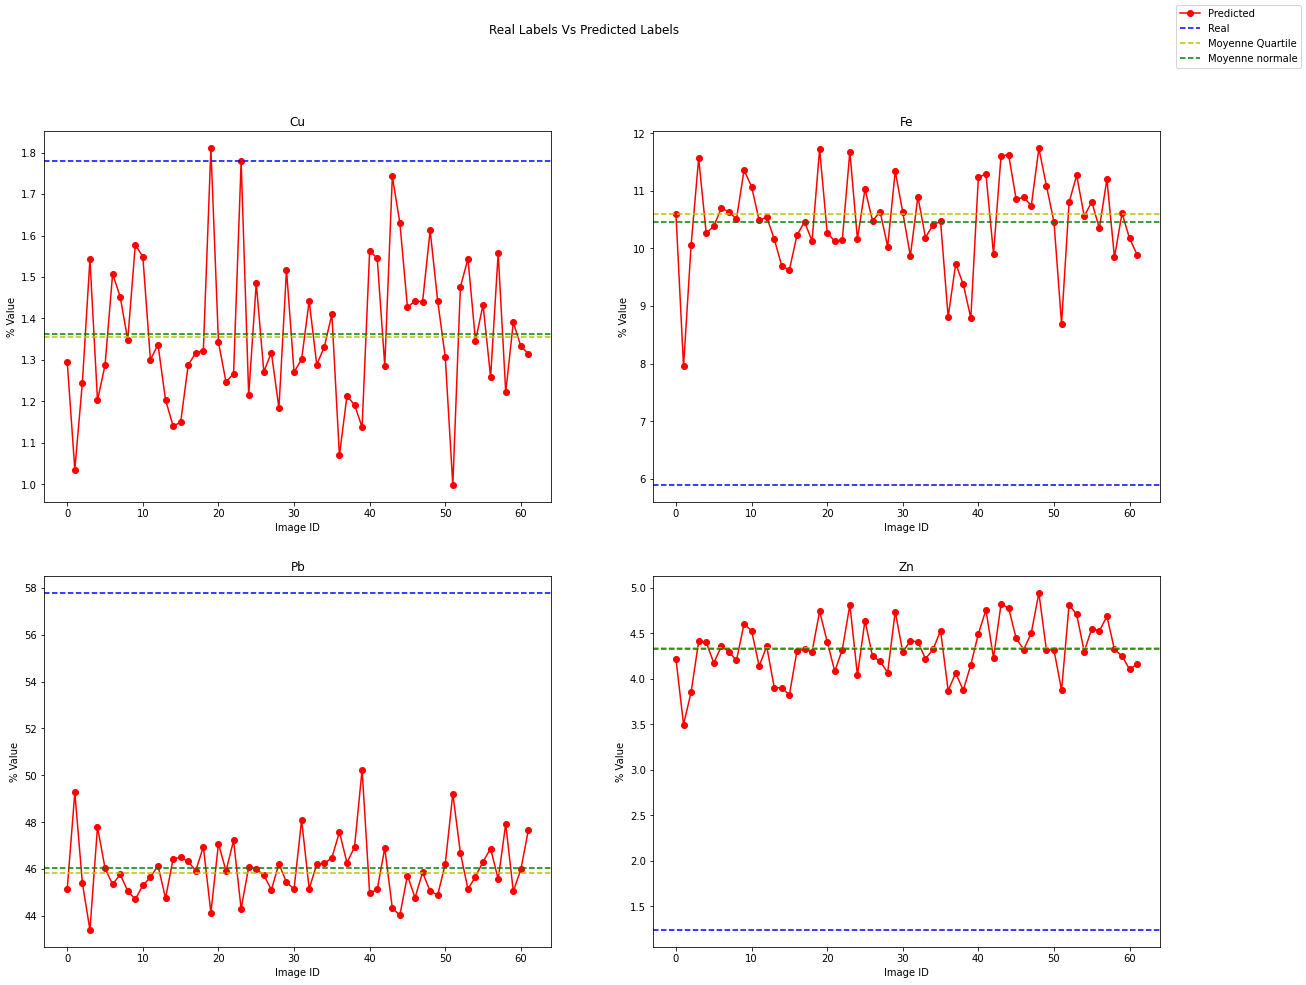

In [43]:
Teneur_predit = predict_video("./video_test/rl4_pb30-6.mp4", msvm)
print("Teneur predits :",Teneur_predit)
Moyenne = CalculMoyenneTenneursPredites(Teneur_predit)
PlotAllTenneurs(Teneur_predit, TeunneurReel, Moyenne)

In [44]:
print(f"Cu: {abs(TeunneurReel[0] - Moyenne[0])}")
print(f"Fe: {abs(TeunneurReel[1] - Moyenne[1])}")
print(f"Pb: {abs(TeunneurReel[2] - Moyenne[2])}")
print(f"Zn: {abs(TeunneurReel[3] - Moyenne[3])}")

Cu: 0.4243597043586924
Fe: 4.705859081401139
Pb: 11.937057715165068
Zn: 3.10219435676784


In [45]:
TeunneurReel = TenneurReel("rl1_pb23-4.mp4", "./Teneurs/DataSource.xlsx")
print("Teneur Reel :",TeunneurReel)

Teneur Reel : (3.01, 23.02, 22.05, 5.82)
